# VIDRA Post-Analysis

Four downstream validation analyses for the PySpark VIDRA pipeline output.

**Analysis 1** — Clinical trial dose-response correlation  
**Analysis 2** — Metabolite-disease directionality  
**Analysis 3** — Therapeutic priority score  
**Analysis 4** — Mechanism of action direction validation

Analyses 1, 2, 3 are independent. Analysis 4 requires the priority score gene list from Analysis 3; its cancer-phenotype list is generated automatically from the OT diseases index (no manual upload).

## Setup & Data Loading


In [1]:
import os
import ast
import shutil
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, spearmanr, fisher_exact, norm, chi2_contingency
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import TheilSenRegressor, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import pyspark.sql.functions as f

from gentropy.common.session import Session
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams["pdf.fonttype"] = 42  # embed fonts as TrueType so text is editable in Illustrator/Inkscape

BUCKET = "vidra-2-0"
GCS_PREFIX = f"gs://{BUCKET}"

# Local cache directory - persists across kernel restarts so re-running the
# notebook does not re-download data each time.
# Store it at the root of the project instead of inside scripts/
DATA_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))),
    "gcs_data",
)
os.makedirs(DATA_DIR, exist_ok=True)

# Output directory for plots and CSVs
OUT_DIR = "post_analysis_results"
os.makedirs(OUT_DIR, exist_ok=True)


def _copy_from_gcs(gcs_path: str, local_path: str, recursive: bool = False) -> None:
    """Copy data from GCS using gcloud storage (preferred) or gsutil."""
    gcloud_bin = shutil.which("gcloud")
    gsutil_bin = shutil.which("gsutil")

    if gcloud_bin:
        if recursive:
            cmd = [gcloud_bin, "storage", "rsync", "--recursive", gcs_path, local_path]
        else:
            cmd = [gcloud_bin, "storage", "cp", gcs_path, local_path]
    elif gsutil_bin:
        if recursive:
            cmd = [gsutil_bin, "-m", "rsync", "-r", gcs_path, local_path]
        else:
            cmd = [gsutil_bin, "cp", gcs_path, local_path]
    else:
        raise RuntimeError(
            "Neither 'gcloud' nor 'gsutil' is available in PATH. "
            "Install Google Cloud SDK and authenticate before running this notebook."
        )

    try:
        # stream output to stdout so we can see progress
        print(f"Running: {' '.join(cmd)}")
        subprocess.run(cmd, check=True, capture_output=False)
    except subprocess.CalledProcessError as e:
        raise RuntimeError(
            f"GCS copy failed for {gcs_path} -> {local_path}. "
            f"Command: {' '.join(cmd)}\nExit code: {e.returncode}"
        ) from e


def _gsutil_cp(gcs_path: str, local_path: str, recursive: bool = False) -> str:
    """Download from GCS if not already cached locally. Returns local_path."""
    if os.path.exists(local_path):
        print(f"  [cached] {os.path.basename(local_path)}")
        return local_path

    if recursive:
        os.makedirs(local_path, exist_ok=True)
    else:
        os.makedirs(os.path.dirname(local_path), exist_ok=True)

    _copy_from_gcs(gcs_path, local_path, recursive=recursive)
    return local_path

Loading BokehJS ...

In [2]:
# -- Download all GCS data to local cache -------------------------------------
# Each path is only downloaded once; subsequent runs use the cached copy.
print("Syncing data from GCS (skipped if already cached)...")

try:
    local_vidra = _gsutil_cp(
        f"{GCS_PREFIX}/vidra_results",
        os.path.join(DATA_DIR, "vidra_results"),
        recursive=True,
    )
    local_molecule = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/open_targets/molecule",
        os.path.join(DATA_DIR, "molecule"),
        recursive=True,
    )
    local_moa = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/open_targets/mechanismOfAction",
        os.path.join(DATA_DIR, "mechanismOfAction"),
        recursive=True,
    )
    local_diseases = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/open_targets/diseases",
        os.path.join(DATA_DIR, "diseases"),
        recursive=True,
    )
    local_ct_csv = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/ManuallyCurated_DoseResponseClinicalTrials.csv",
        os.path.join(DATA_DIR, "ManuallyCurated_DoseResponseClinicalTrials.csv"),
    )
    local_met_txt = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/metabolite_disease_pairs.txt",
        os.path.join(DATA_DIR, "metabolite_disease_pairs.txt"),
    )
except RuntimeError as e:
    raise RuntimeError(
        "Failed to sync required VIDRA inputs from GCS. "
        "Verify bucket access and authentication (for example, run 'gcloud auth login' and 'gcloud auth application-default login').\n"
        f"Root cause: {e}"
    ) from e

print("\nLoading VIDRA results from local cache...")
vidra_raw = pd.read_parquet(local_vidra)
print(f"  {len(vidra_raw):,} rows, columns: {list(vidra_raw.columns)}")

required_cols = {
    "parameter",
    "gene",
    "as_disease",
    "mean",
    "median",
    "pp_slope_pos",
    "pp_slope_neg",
    "source",
    "qtl",
    "n_variants",
}
missing = required_cols - set(vidra_raw.columns)
if missing:
    raise ValueError(f"VIDRA results parquet is missing expected columns: {missing}")
print("  Column check passed.")

Syncing data from GCS (skipped if already cached)...
  [cached] vidra_results
  [cached] molecule
  [cached] mechanismOfAction
  [cached] diseases
  [cached] ManuallyCurated_DoseResponseClinicalTrials.csv
  [cached] metabolite_disease_pairs.txt

Loading VIDRA results from local cache...
  721,937 rows, columns: ['gene', 'as_disease', 'parameter', 'model', 'n_variants', 'source', 'qtl', 'mean', 'median', 'pct_1', 'pct_2_5', 'pct_5', 'pct_10', 'pct_25', 'pct_40', 'pct_50', 'pct_60', 'pct_75', 'pct_90', 'pct_95', 'pct_97_5', 'pct_99', 'pp_slope_pos', 'pp_slope_neg', 'has_burden']
  Column check passed.


In [3]:
# ── Common threshold filter ───────────────────────────────────────────────────
# ClinVar-only models (source in ['2','[2]']) require PP > 0.70.
# All other models (QTL-informed, coding GWAS, AZ rare) require PP > 0.55.
# Note: Only source=='2'/'[2]' is ClinVar-only.


def threshold_df(
    df: pd.DataFrame, threshold_rare: float = 0.70, threshold_other: float = 0.55
) -> pd.Series:
    """Return a boolean mask keeping rows with confident slope estimates."""
    is_clinvar_only = df["source"].isin(["2", "[2]"])
    pp_max = df[["pp_slope_pos", "pp_slope_neg"]].max(axis=1)
    return (is_clinvar_only & (pp_max > threshold_rare)) | (
        ~is_clinvar_only & (pp_max > threshold_other)
    )


# ── Base filtered slope dataframe (used by all analyses) ─────────────────────
df_slope = vidra_raw[vidra_raw["parameter"] == "slope"].copy()
df_slope = df_slope[threshold_df(df_slope)].reset_index(drop=True)

intercept_by_pair = vidra_raw[vidra_raw["parameter"] == "intercept"][
    ["gene", "as_disease", "mean", "median"]
].rename(columns={"mean": "intercept_mean", "median": "intercept_median"})
df_slope = df_slope.merge(intercept_by_pair, on=["gene", "as_disease"], how="left")
df_slope["has_intercept"] = df_slope["intercept_mean"].notna().astype(int)
df_slope["intercept_mean"] = df_slope["intercept_mean"].fillna(0.0)
# df_slope = df_slope[df_slope["model"] != 'single_variant']

print(f"Slope rows after threshold filter: {len(df_slope):,}")

Slope rows after threshold filter: 80,634


In [4]:
vidra_raw[vidra_raw["parameter"] == "slope"].shape[0]

148350

In [5]:
df_slope[df_slope['model'] == 'single_variant'].value_counts('source')


source
0    51573
1     1235
2      112
Name: count, dtype: int64

In [6]:
df_slope

,gene,as_disease,parameter,model,n_variants,source,qtl,mean,median,pct_1,...,pct_90,pct_95,pct_97_5,pct_99,pp_slope_pos,pp_slope_neg,has_burden,intercept_mean,intercept_median,has_intercept
0,ENSG00000140968,EFO_0007978,slope,single_variant,1,0,0,-0.186672,-0.189148,-0.927462,...,0.211852,0.342880,0.425377,0.513530,0.257,0.743,False,0.000000,NaN,0
1,ENSG00000118640,EFO_0005090,slope,single_variant,1,0,0,0.192818,0.192331,0.131048,...,0.226329,0.236501,0.242772,0.251352,1.000,0.000,False,0.000000,NaN,0
2,ENSG00000243943,EFO_0020069,slope,single_variant,1,0,0,-2.534342,-2.537745,-3.169962,...,-2.138750,-2.032627,-1.947466,-1.848996,0.000,1.000,False,0.000000,NaN,0
3,ENSG00000151690,EFO_0004617,slope,single_variant,1,0,0,1.003386,0.987374,-0.190957,...,1.713087,1.893576,2.020728,2.194995,0.980,0.020,False,0.000000,NaN,0
4,ENSG00000108433,MONDO_0004634,slope,single_variant,1,0,0,-1.709915,-1.703315,-2.363624,...,-1.325063,-1.241225,-1.164423,-1.049497,0.000,1.000,False,0.000000,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80629,ENSG00000117360,EFO_0005091,slope,single_variant,1,0,0,0.929672,0.907263,-0.594737,...,1.838460,2.076568,2.300370,2.529005,0.923,0.077,False,0.000000,NaN,0
80630,ENSG00000124787,EFO_0000508,slope,multiple_variant_fullrank,8,[2],[2],-0.427406,-0.422396,-2.269768,...,0.595061,0.855808,1.081101,1.376898,0.295,0.705,True,2.621889,2.633605,1
80631,ENSG00000048471,EFO_0009270,slope,single_variant,1,0,0,0.150896,0.150441,0.106371,...,0.175423,0.182585,0.187279,0.193617,1.000,0.000,False,0.000000,NaN,0
80632,ENSG00000185862,EFO_0010972,slope,single_variant,1,0,0,0.132231,0.132026,0.089265,...,0.155432,0.161741,0.165617,0.172390,1.000,0.000,False,0.000000,NaN,0


---

## Analysis 1 — Clinical Trial Dose-Response Correlation

Correlates VIDRA slope estimates with regression slopes derived from manually curated
clinical trial dose-response data.


In [7]:
# ── Load clinical trial data ──────────────────────────────────────────────────
df_slope_a1 = vidra_raw[(vidra_raw["parameter"] == "slope")].copy()
df_slope_a1 = df_slope_a1[threshold_df(df_slope_a1, 0.70, 0.55)].reset_index(drop=True)
print(f"Slope rows for Analysis 1: {len(df_slope_a1):,}")

clinical_trials = pd.read_csv(local_ct_csv, encoding="latin1")
print(f"Clinical trials rows: {len(clinical_trials):,}")
print(clinical_trials.head(3))

Slope rows for Analysis 1: 80,634
Clinical trials rows: 63
         study   Gene           GeneId                 Phenotype  PhenotypeId  \
0  NCT05261126  PCSK9  ENSG00000169174  cholesterol measurements  EFO_0004574   
1  NCT05261126  PCSK9  ENSG00000169174  cholesterol measurements  EFO_0004574   
2  NCT05261126  PCSK9  ENSG00000169174  cholesterol measurements  EFO_0004574   

      Drug  Unit  Drug concentration                      Response  \
0  MK-0616    mg                 6.0  mean percent change in LDL-C   
1  MK-0616    mg                12.0  mean percent change in LDL-C   
2  MK-0616    mg                18.0  mean percent change in LDL-C   

   Response outcome              CI  sd  \
0              40.0  [-45.2; -34.8] NaN   
1              54.5  [-59.8; -49.2] NaN   
2              57.9  [-63.2; -52.6] NaN   

                                               notes  
0  These values have been transformed (i.e. *-1) ...  
1  These values have been transformed (i.e. *-1) ...

In [8]:
# ── Compute RLM regression slope per (study, gene, phenotype) ─────────────────
# Use add_constant when n > 2: a 2-parameter model on only 2 points gives
# df_resid=0 and a ZeroDivisionError in RLM's variance calculation.
def _rlm_slope(x):
    exog = (
        sm.add_constant(x["Drug concentration"])
        if len(x) > 2
        else x["Drug concentration"]
    )
    return sm.RLM(endog=x["Response outcome"], exog=exog).fit().params["Drug concentration"]


clinical_trials_slopes = (
    clinical_trials.groupby(["study", "GeneId", "PhenotypeId"])
    .apply(_rlm_slope, include_groups=False)
    .reset_index()
    .rename(columns={0: "stats_regression"})
)

# ── Merge with VIDRA results ──────────────────────────────────────────────────
merged_ct = pd.merge(
    clinical_trials_slopes,
    df_slope_a1,
    left_on=["PhenotypeId", "GeneId"],
    right_on=["as_disease", "gene"],
    how="inner",
).drop_duplicates()
print(f"Merged rows: {len(merged_ct):,}")

Merged rows: 11


In [9]:
# ── Correlation ───────────────────────────────────────────────────────────────
pearson_r, pearson_p = pearsonr(merged_ct["stats_regression"], merged_ct["mean"])
spearman_r, spearman_p = spearmanr(merged_ct["stats_regression"], merged_ct["mean"])
print(f"Pearson  r={pearson_r:.3f}  p={pearson_p:.4g}")
print(f"Spearman r={spearman_r:.3f}  p={spearman_p:.4g}")

# Robust regression
rlm_model = smf.rlm("stats_regression ~ mean", data=merged_ct).fit()
merged_ct["predictY"] = rlm_model.predict(exog=merged_ct[["mean"]])
slope_estimate = np.round(rlm_model.params["mean"], 3)
pval = rlm_model.pvalues["mean"]
print(rlm_model.summary())

Pearson  r=0.492  p=0.1243
Spearman r=0.763  p=0.006351
                    Robust linear Model Regression Results                    
Dep. Variable:       stats_regression   No. Observations:                   11
Model:                            RLM   Df Residuals:                        9
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Wed, 03 Jun 2026                                         
Time:                        14:34:01                                         
No. Iterations:                    21                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [10]:
print(f"{rlm_model.pvalues['mean']:.2e}")

1.71e-04


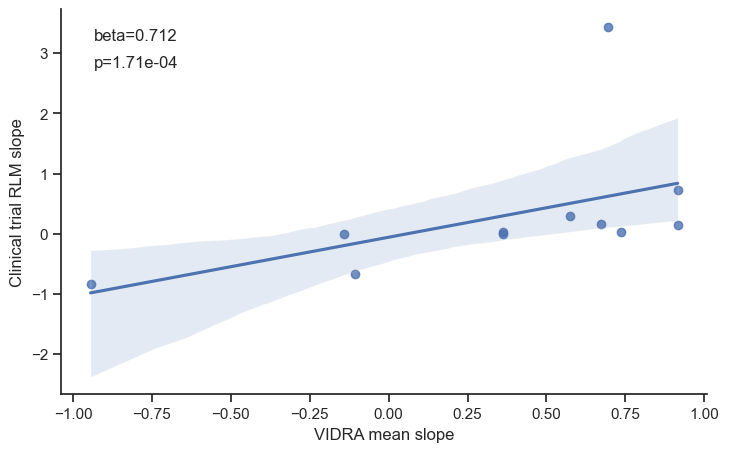

In [11]:
# ── Plot ──────────────────────────────────────────────────────────────────────
dpi = 300
fig, ax = plt.subplots(figsize=(2500 / dpi, 1500 / dpi))
sns.regplot(data=merged_ct, x="mean", y="stats_regression", scatter=True, ax=ax)
ax.text(0.05, 0.95, f"beta={slope_estimate}", transform=ax.transAxes, va="top")
ax.text(0.05, 0.88, f"p={pval:.2e}", transform=ax.transAxes, va="top")
ax.set_xlabel("VIDRA mean slope")
ax.set_ylabel("Clinical trial RLM slope")
fig.savefig(
    os.path.join(OUT_DIR, "A1_dose_response_correlation.pdf"),
    dpi=dpi,
    bbox_inches="tight",
)
plt.show()

In [12]:
vidra_raw[
    (vidra_raw["parameter"] == "slope") 
    & (vidra_raw["gene"] == "ENSG00000164116")
    # & (vidra_raw["as_disease"] == "EFO_0001073")
].sort_values('n_variants', ascending=False)

,gene,as_disease,parameter,model,n_variants,source,qtl,mean,median,pct_1,...,pct_50,pct_60,pct_75,pct_90,pct_95,pct_97_5,pct_99,pp_slope_pos,pp_slope_neg,has_burden
294812,ENSG00000164116,EFO_0000508,slope,multiple_variant_fullrank,15,[2],[2],-0.118339,-0.106626,-2.161102,...,-0.106626,0.119971,0.502935,1.000991,1.324022,1.626464,1.901010,0.450,0.550,False
704479,ENSG00000164116,MONDO_0014331,slope,multiple_variant_fullrank,6,[2],[2],-0.535717,-0.569520,-2.387405,...,-0.569520,-0.336209,0.027022,0.500469,0.749078,1.031681,1.282978,0.261,0.739,False
449728,ENSG00000164116,EFO_0000537,slope,multiple_variant_fullrank,4,"[0, 1]","[0, 2]",-0.944694,-0.928917,-2.170875,...,-0.928917,-0.797785,-0.586487,-0.317605,-0.113978,0.123096,0.359133,0.036,0.964,True
338776,ENSG00000164116,EFO_0000479,slope,multiple_variant_fullrank,3,[1],[2],-0.959734,-0.963635,-2.216384,...,-0.963635,-0.816976,-0.580997,-0.243116,-0.055543,0.082823,0.318301,0.035,0.965,True
125773,ENSG00000164116,MONDO_0001134,slope,multiple_variant_fullrank,2,"[0, 1]","[0, 2]",-0.733082,-0.741128,-2.001143,...,-0.741128,-0.606771,-0.361982,0.002878,0.226483,0.356015,0.560957,0.103,0.897,True
210681,ENSG00000164116,EFO_0006336,slope,multiple_variant_fullrank,2,[0],[0],-0.164224,-0.219848,-5.490737,...,-0.219848,0.462160,1.392990,2.860016,3.778856,4.376729,5.205767,0.464,0.536,True
221809,ENSG00000164116,EFO_0006335,slope,multiple_variant_fullrank,2,[0],[0],-0.130077,-0.180281,-5.015112,...,-0.180281,0.436315,1.303060,2.651165,3.490087,4.047171,4.802876,0.468,0.532,True
359325,ENSG00000164116,EFO_0004587,slope,multiple_variant_fullrank,2,[0],[0],-0.120949,-0.156262,-2.940100,...,-0.156262,0.197672,0.700198,1.475007,1.972788,2.292762,2.733200,0.460,0.540,False
15900,ENSG00000164116,EFO_0007988,slope,single_variant,1,0,0,-0.134941,-0.135249,-0.183876,...,-0.135249,-0.130164,-0.121102,-0.108700,-0.101455,-0.097099,-0.089566,0.000,1.000,False
226322,ENSG00000164116,GO_0042493,slope,single_variant,1,0,0,-0.596368,-0.595270,-0.830966,...,-0.595270,-0.568192,-0.521502,-0.463233,-0.431476,-0.399378,-0.364460,0.000,1.000,False


In [13]:
clinical_trials_slopes[
    clinical_trials_slopes['GeneId'] == 'ENSG00000164116'
]

,study,GeneId,PhenotypeId,stats_regression
17,NCT03217591,ENSG00000164116,EFO_0000537,-0.83


In [14]:
merged_ct[["study", "GeneId", "PhenotypeId", "stats_regression", "mean", "predictY"]]

,study,GeneId,PhenotypeId,stats_regression,mean,predictY
0,NCT00283439,ENSG00000117400,HP_0001873,0.023313,0.735753,0.325990
1,NCT00666848,ENSG00000159640,EFO_0000537,-0.668000,-0.106214,-0.273200
2,NCT00787150,ENSG00000126218,EFO_0000275,3.440000,0.694023,0.296293
3,NCT01000506,ENSG00000113525,MONDO_0004979,0.001051,0.362891,0.060640
4,NCT01270464,ENSG00000113525,MONDO_0004979,0.031787,0.362891,0.060640
5,NCT01375777,ENSG00000169174,EFO_0004574,0.142143,0.915969,0.454242
6,NCT01812707,ENSG00000169174,HP_0003124,0.158923,0.673357,0.281585
7,NCT02819635,ENSG00000096968,EFO_0000729,0.289040,0.573213,0.210318
8,NCT02918019,ENSG00000115602,MONDO_0004979,-0.000184,-0.143025,-0.299397
9,NCT03217591,ENSG00000164116,EFO_0000537,-0.830000,-0.944694,-0.869909


---

## Analysis 2 — Metabolite-Disease Directionality

Tests whether VIDRA slope signs are concordant across metabolite and disease phenotypes
that share causal genes.


In [15]:
# ── Load metabolite-disease pairs ─────────────────────────────────────────────
with open(local_met_txt, "r") as fh:
    MetDis = [
        ast.literal_eval(line.split("#")[0])
        for line in fh
        if not line.strip().startswith("#") and line.strip()
    ]
print(f"Metabolite-disease pairs loaded: {len(MetDis)}")

Metabolite-disease pairs loaded: 572


In [16]:
# ── Match metabolites and diseases via shared genes ───────────────────────────
def metabolite_disease_matching(df: pd.DataFrame, met_dis_pairs: list) -> pd.DataFrame:
    rows = []
    for met, dis in met_dis_pairs:
        df_met = df[df["as_disease"] == met]
        df_dis = df[df["as_disease"] == dis]
        if df_met.empty or df_dis.empty:
            continue
        shared = pd.merge(df_met, df_dis, on="gene", suffixes=("_met", "_dis"))
        for _, row in shared.iterrows():
            rows.append(
                {
                    "metabolite": met,
                    "disease": dis,
                    "gene": row["gene"],
                    "Mean_metabolite": float(row["mean_met"]),
                    "Mean_disease": float(row["mean_dis"]),
                    "conf_metabolite": float(row["pp_slope_neg_met"]),
                    "conf_disease": float(row["pp_slope_neg_dis"]),
                }
            )
    return pd.DataFrame(rows)


MetDiseDF = metabolite_disease_matching(df_slope, MetDis)
print(f"Matched gene-pairs: {len(MetDiseDF):,}")

Matched gene-pairs: 2,887


In [17]:
# ── Quadrant labels ───────────────────────────────────────────────────────────
def _sign(x, y):
    sx = "+" if x > 0 else "-"
    sy = "+" if y > 0 else "-"
    return sx + sy


MetDiseDF["sign"] = MetDiseDF.apply(
    lambda r: _sign(r["Mean_metabolite"], r["Mean_disease"]), axis=1
)
MetDiseDF["sign_general"] = MetDiseDF["sign"].apply(
    lambda s: "+" if s in ("++", "--") else "-"
)

# ── Gaussian mixture clustering ───────────────────────────────────────────────
sign_num, sign_index = pd.factorize(MetDiseDF["sign"])
X_clust = np.column_stack(
    [
        MetDiseDF["Mean_metabolite"],
        MetDiseDF["Mean_disease"],
        sign_num,
    ]
)
y_pred = GaussianMixture(
    n_components=4, init_params="kmeans", random_state=64
).fit_predict(X_clust)
MetDiseDF["clusters"] = y_pred.astype(str)

In [18]:
# ── Theil-Sen robust regression per quadrant ──────────────────────────────────
def _robust_slope(sub: pd.DataFrame) -> float:
    X = sub["Mean_metabolite"].values.reshape(-1, 1)
    y = sub["Mean_disease"].values
    return TheilSenRegressor().fit(X, y).coef_[0]


observed_slopes = MetDiseDF.groupby("sign").apply(_robust_slope)
print("Observed Theil-Sen slopes per quadrant:")
print(observed_slopes)

Observed Theil-Sen slopes per quadrant:
sign
++    0.281007
+-   -0.301891
-+   -0.174023
--    0.507196
dtype: float64


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_44986/4209634540.py:8: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



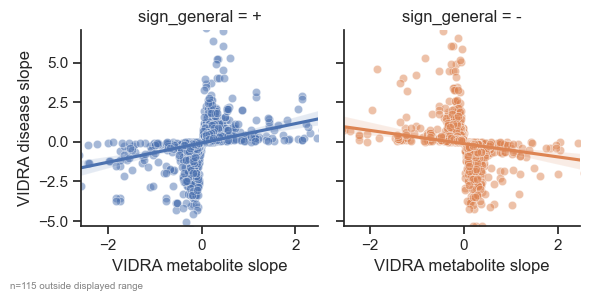

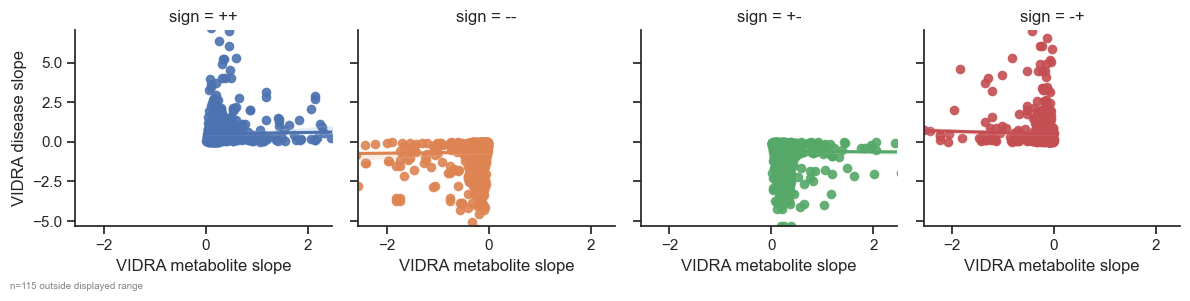

In [19]:
# ── Scatter plots ─────────────────────────────────────────────────────────────
# Clip display to 2.5–97.5th percentile on each axis; regression is fit on all data.
x_lo, x_hi = MetDiseDF["Mean_metabolite"].quantile([0.01, 0.99])
y_lo, y_hi = MetDiseDF["Mean_disease"].quantile([0.01, 0.99])
n_clipped = (
    (MetDiseDF["Mean_metabolite"] < x_lo) | (MetDiseDF["Mean_metabolite"] > x_hi)
    | (MetDiseDF["Mean_disease"] < y_lo) | (MetDiseDF["Mean_disease"] > y_hi)
).sum()

g = sns.FacetGrid(
    MetDiseDF,
    col="sign_general",
    sharex=False,
    sharey=True,
    hue="sign_general",
    hue_order=["+", "-"],
    col_order=["+", "-"],
)
g.map(sns.scatterplot, "Mean_metabolite", "Mean_disease", alpha=0.5)
g.map(sns.regplot, "Mean_metabolite", "Mean_disease", scatter=False, robust=True)
g.set_axis_labels("VIDRA metabolite slope", "VIDRA disease slope")
g.set(xlim=(x_lo, x_hi), ylim=(y_lo, y_hi))
if n_clipped:
    g.figure.text(0.01, 0.01, f"n={n_clipped} outside displayed range",
                  fontsize=7, color="grey", ha="left")
g.figure.savefig(
    os.path.join(OUT_DIR, "A2_metabolite_disease_general.pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

g2 = sns.FacetGrid(
    MetDiseDF,
    col="sign",
    sharex=False,
    sharey=True,
    hue="sign",
    hue_order=["++", "--", "+-", "-+"],
    col_order=["++", "--", "+-", "-+"],
)
g2.map(sns.scatterplot, "Mean_metabolite", "Mean_disease", alpha=0.5)
g2.map(sns.regplot, "Mean_metabolite", "Mean_disease", robust=True)
g2.set_axis_labels("VIDRA metabolite slope", "VIDRA disease slope")
g2.set(xlim=(x_lo, x_hi), ylim=(y_lo, y_hi))
if n_clipped:
    g2.figure.text(0.01, 0.01, f"n={n_clipped} outside displayed range",
                   fontsize=7, color="grey", ha="left")
g2.figure.savefig(
    os.path.join(OUT_DIR, "A2_metabolite_disease_quadrants.pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [20]:
# ── Bootstrap permutation test ───────────────────────────────────────────────
N_BOOT = 1_0
n_pairs = len(MetDiseDF)
boot_slopes = {s: np.empty(N_BOOT) for s in ["++", "--", "+-", "-+"]}

for i in range(N_BOOT):
    sample = df_slope.sample(n=n_pairs * 2, replace=True)
    half = n_pairs
    df1 = sample.iloc[:half][["mean"]].reset_index(drop=True)
    df2 = sample.iloc[half:2*half][["mean"]].reset_index(drop=True)
    rnd = pd.DataFrame({"Mean_x": df1["mean"], "Mean_y": df2["mean"]})
    rnd["sign"] = rnd.apply(lambda r: _sign(r["Mean_x"], r["Mean_y"]), axis=1)
    try:
        for s in boot_slopes:
            sub = rnd[rnd["sign"] == s]
            if len(sub) > 1:
                X = sub["Mean_x"].values.reshape(-1, 1)
                boot_slopes[s][i] = TheilSenRegressor().fit(X, sub["Mean_y"].values).coef_[0]
    except Exception:
        pass

# P-values: ++ and -- expect positive slope; +- and -+ expect negative slope
for s, direction in {"++": ">", "--": ">", "+-": "<", "-+": "<"}.items():
    obs = observed_slopes.get(s, np.nan)
    if direction == ">":
        p = (np.sum(boot_slopes[s] > obs) + 1 / N_BOOT) / N_BOOT
    else:
        p = (np.sum(boot_slopes[s] < obs) + 1 / N_BOOT) / N_BOOT
    print(f"sign={s}  observed_slope={obs:.4f}  p={p:.10g}")

sign=++  observed_slope=0.2810  p=0.01
sign=--  observed_slope=0.5072  p=0.01
sign=+-  observed_slope=-0.3019  p=0.01
sign=-+  observed_slope=-0.1740  p=0.01


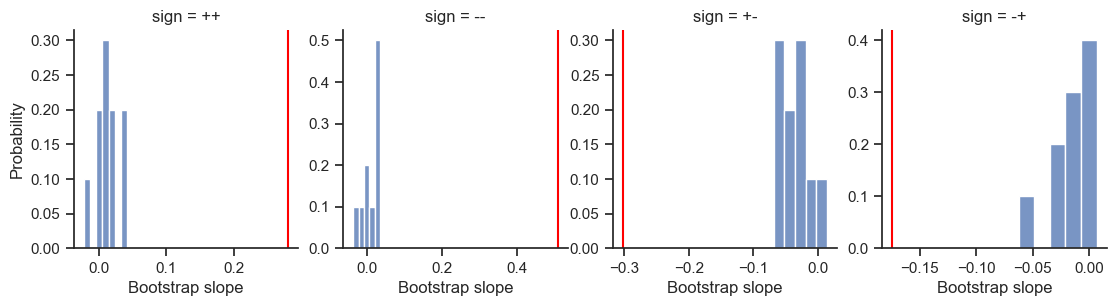

In [21]:
# ── Bootstrap distribution plots ──────────────────────────────────────────────
dpi = 600
fig, axs = plt.subplots(1, 4, figsize=(8000 / dpi, 1700 / dpi))
for ax, s in zip(axs, ["++", "--", "+-", "-+"]):
    sns.histplot(boot_slopes[s], ax=ax, stat="probability")
    ax.axvline(x=observed_slopes.get(s, 0), color="red")
    ax.set_title(f"sign = {s}")
    ax.set_xlabel("Bootstrap slope")
axs[0].set_ylabel("Probability")
for ax in axs[1:]:
    ax.set_ylabel("")
fig.savefig(os.path.join(OUT_DIR, "A2_bootstrap_distributions.pdf"), dpi=dpi, bbox_inches="tight")
plt.show()

---

## Analysis 3 — Therapeutic Priority Score

Trains a stacking classifier to distinguish approved drug targets from non-targets
using VIDRA slope features, then applies it to all VIDRA results.


In [22]:
# ── Load OT molecule data ─────────────────────────────────────────────────────
print("Loading OT molecule data from local cache...")
moleculeInfo = pd.read_parquet(local_molecule)
# moleculeInfo = moleculeInfo[moleculeInfo['maximumClinicalTrialPhase'].isin([1, 2, 3, 4])].reset_index(drop=True)

targets_norm = pd.json_normalize(moleculeInfo["linkedTargets"])
targets_norm.columns = ["targetId", "targetcount"]
disease_norm = pd.json_normalize(moleculeInfo["linkedDiseases"])
disease_norm.columns = ["diseaseId", "diseasecount"]

molInfo = pd.concat(
    [
        moleculeInfo[
            ["id", "yearOfFirstApproval", "maximumClinicalTrialPhase", "isApproved"]
        ],
        targets_norm,
        disease_norm,
    ],
    axis=1,
).dropna(subset=["targetId", "diseaseId"])
molInfo = molInfo.explode("targetId").explode("diseaseId")
molInfo.dropna(subset=["targetId", "diseaseId"], inplace=True)

# Highest phase per gene — gene-level dedup for the gene-only join used in
# Analysis 3. Analysis 3b builds its own per-(gene, disease) label table.
molecules_G = (
    molInfo.sort_values(by="maximumClinicalTrialPhase", ascending=False)
    .drop_duplicates(subset="targetId", keep="first")
    .dropna(subset=["targetId"])
)
print(f"Unique drug targets: {molecules_G.targetId.nunique():,}")


Loading OT molecule data from local cache...
Unique drug targets: 1,508


In [23]:
# ── Build training dataset ────────────────────────────────────────────────────
# Gene-only join: every VIDRA row for a drug-targeted gene becomes a positive,
# regardless of indication. Matches the legacy "is this gene a known drug
# target?" framing. The (gene, disease)-grain version lives in Analysis 3b.
#
# Negatives: 100 unique genes with no ChEMBL drug. Sample unique genes first
# then keep one VIDRA row each, so the negative set isn't dominated by genes
# that happen to have many slope rows.
candidate_neg_genes = (
    df_slope.loc[~df_slope["gene"].isin(molecules_G["targetId"]), "gene"]
    .drop_duplicates()
)
neg_genes = candidate_neg_genes.sample(100, random_state=1)
not_targets = (
    df_slope[df_slope["gene"].isin(neg_genes)]
    .drop_duplicates(subset="gene", keep="first")
)

as_train = df_slope.merge(
    molecules_G[
        [
            "isApproved",
            "targetId",
            "maximumClinicalTrialPhase",
            "yearOfFirstApproval",
        ]
    ],
    left_on="gene",
    right_on="targetId",
    how="inner",
)
as_train = pd.concat([as_train, not_targets]).drop_duplicates(keep="first")

as_train["isApproved"] = as_train["maximumClinicalTrialPhase"] > 3
as_train["maximumClinicalTrialPhase"] = as_train["maximumClinicalTrialPhase"].fillna(0)

print(
    f"Training set: {len(as_train):,} rows  (approved={as_train['isApproved'].sum()})"
)


Training set: 7,941 rows  (approved=4362)


In [24]:
# ── Train stacking classifier ─────────────────────────────────────────────────
X = pd.get_dummies(
    as_train[
        [
            "mean",
            "n_variants",
            "source",
            "qtl",
            "pp_slope_neg",
            # "has_burden",
            # "intercept_mean",
            # "has_intercept",
        ]
    ],
    columns=["source", "qtl"],
)
y = as_train["isApproved"].replace({True: 1, False: 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

estimators = [
    ("gbc", GradientBoostingClassifier(random_state=42, n_estimators=50)),
    ("svc", make_pipeline(StandardScaler(), LinearSVC(random_state=42))),
    (
        "gpc",
        make_pipeline(StandardScaler(), GaussianProcessClassifier(random_state=42)),
    ),
]
clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
clf.fit(X_train, y_train)

accuracy = accuracy_score(y_test, clf.predict(X_test))
roc_auc_proba = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(
    f"Test accuracy: {accuracy:.3f}  ROC AUC (proba): {roc_auc_proba:.3f}"
)


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_44986/795304088.py:17: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Test accuracy: 0.580  ROC AUC (proba): 0.611


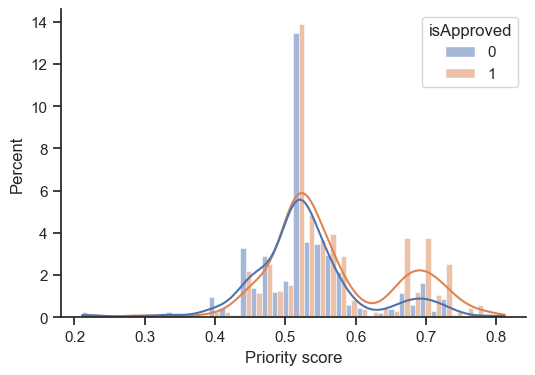

In [25]:
# ── Priority score distribution on test set ───────────────────────────────────
X_test = X_test.copy()
X_test["predictions"] = clf.predict_proba(X_test)[:, 1]
X_test["isApproved"] = y_test.values

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(
    X_test,
    x="predictions",
    hue="isApproved",
    kde=True,
    bins=40,
    multiple="dodge",
    stat="percent",
    ax=ax,
)
ax.set_xlabel("Priority score")
fig.savefig(
    os.path.join(OUT_DIR, "A3_priority_score_distribution.pdf"),
    dpi=400,
    bbox_inches="tight",
)
plt.show()

In [26]:
# ── Expand prediction to all VIDRA results ────────────────────────────────────
# Align dummy columns to training feature set
all_features = pd.get_dummies(
    df_slope[
        [
            "mean",
            "n_variants",
            "source",
            "qtl",
            "pp_slope_neg",
            # "has_burden",
            # "intercept_mean",
            # "has_intercept",
        ]
    ],
    columns=["source", "qtl"],
).reindex(columns=X_train.columns, fill_value=0)

df_slope_pred = df_slope.copy()
df_slope_pred["prediction"] = clf.predict_proba(all_features)[:, 1]

# Gene-level label: a gene gets isApproved=1 if it is the target of any
# phase-4 drug, regardless of indication. Matches the gene-only training
# grain. (Analysis 3b uses a (gene, disease) label.)
approved_genes = set(
    molecules_G.loc[molecules_G["maximumClinicalTrialPhase"] > 3, "targetId"]
)
df_slope_pred["isApproved"] = df_slope_pred["gene"].isin(approved_genes).astype(int)

# Sanity check: TYK2 and PCSK9 should appear at high scores
for name, ensg in [("TYK2", "ENSG00000105397"), ("PCSK9", "ENSG00000169174")]:
    sub = df_slope_pred[df_slope_pred["gene"] == ensg]
    if not sub.empty:
        print(f"{name} max prediction: {sub['prediction'].max():.3f}")
    else:
        print(f"{name} not found in VIDRA results")


TYK2 max prediction: 0.605
PCSK9 max prediction: 0.800


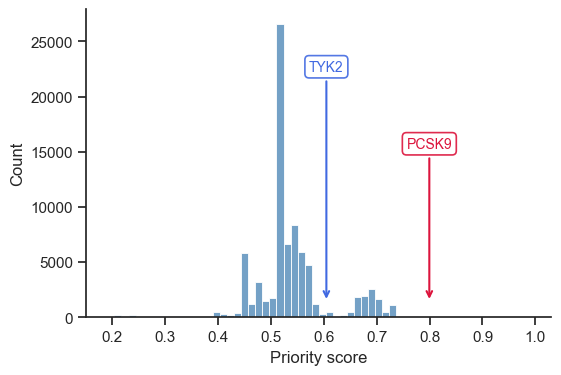

In [27]:
# ── Priority score histogram (all genes) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(
    df_slope_pred, x="prediction", ax=ax,
    bins=60, color="steelblue",
    edgecolor="white", linewidth=0.6,
)

# Stagger labels vertically so they don't collide even when x-values are close.
y_max = ax.get_ylim()[1]
label_configs = [
    ("TYK2",  "ENSG00000105397", "royalblue", 0.80),
    ("PCSK9", "ENSG00000169174", "crimson",   0.55),
]
for name, ensg, color, y_frac in label_configs:
    sub = df_slope_pred[df_slope_pred["gene"] == ensg]
    if not sub.empty:
        x_val = sub["prediction"].max()
        ax.annotate(
            name,
            xy=(x_val, y_max * 0.05),
            xytext=(x_val, y_max * y_frac),
            xycoords="data",
            textcoords="data",
            arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
            ha="center",
            fontsize=10,
            color=color,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=color, linewidth=1.2, alpha=0.9),
        )

ax.set_xlabel("Priority score")
ax.set_ylabel("Count")
fig.savefig(
    os.path.join(OUT_DIR, "A3_priority_score_all_genes.pdf"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()


In [28]:
# ── Fisher enrichment at priority score thresholds ───────────────────────────
DrugPrediction = (
    df_slope_pred[
        [
            "prediction",
            "gene",
            "as_disease",
            "mean",
            "n_variants",
            "source",
            "qtl",
            "pp_slope_neg",
        ]
    ]
    .merge(
        molecules_G[["maximumClinicalTrialPhase", "isApproved", "targetId"]],
        left_on="gene",
        right_on="targetId",
        how="inner",
    )
    .sort_values(by="maximumClinicalTrialPhase", ascending=False)
    .drop_duplicates(subset="gene", keep="first")
    .dropna()
)
DrugPrediction["isApproved"] = DrugPrediction["isApproved"].replace({True: 1, False: 0})

no_target_approved = sum(
    moleculeInfo[moleculeInfo["linkedTargets"].isna()]["isApproved"].dropna()
)
no_target_not_approved = sum(
    moleculeInfo[moleculeInfo["linkedTargets"].isna()]["isApproved"] == 0
)

or_rows = []
for threshold in np.arange(0.401, 0.9, 0.1):
    above = DrugPrediction[DrugPrediction["prediction"] >= threshold]
    ct = [
        [above["isApproved"].sum() + 0.5, (above["isApproved"] == 0).sum() + 0.5],
        [no_target_approved + 0.5, no_target_not_approved + 0.5],
    ]
    or_val, p_val = fisher_exact(ct)
    se = np.sqrt(sum(1 / cell for row in ct for cell in row))
    ci_lo = np.exp(np.log(or_val) - norm.ppf(0.975) * se)
    ci_hi = np.exp(np.log(or_val) + norm.ppf(0.975) * se)
    or_rows.append(
        {
            "Threshold": round(threshold, 2),
            "OR": or_val,
            "ci_L": ci_lo,
            "ci_U": ci_hi,
            "pval": p_val,
        }
    )

orDF = pd.DataFrame(or_rows)
print(orDF.to_string(index=False))


 Threshold        OR      ci_L      ci_U          pval
       0.4  6.603202  5.745275  7.589241 3.210797e-164
       0.5  7.102492  6.122140  8.239831 5.223173e-157
       0.6 10.734937  8.512137 13.538184 3.851563e-104
       0.7 24.863886 14.487129 42.673246  2.784474e-49
       0.8       NaN       NaN       NaN  1.000000e+00


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_44986/3617734522.py:25: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_44986/3809977377.py:3: UserWarning:



The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.




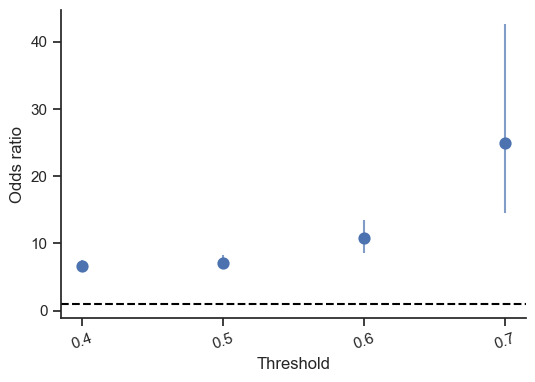

High-priority genes saved: 6,882  →  post_analysis_results/genelist_with_priorityScore_greater_than07.csv


In [ ]:
# ── Forest plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.pointplot(data=orDF, x="Threshold", y="OR", join=False, ax=ax)
ax.vlines(
    x=orDF["Threshold"].astype(str),
    ymin=orDF["ci_L"],
    ymax=orDF["ci_U"],
    alpha=0.7,
)
ax.axhline(y=1, color="black", linestyle="--")
ax.set_ylabel("Odds ratio")
plt.xticks(rotation=20)
fig.savefig(os.path.join(OUT_DIR, "A3_OR_enrichment.pdf"), dpi=600, bbox_inches="tight")
plt.show()

# ── Save gene list for Analysis 4 ────────────────────────────────────────────
priority_genes = df_slope_pred[df_slope_pred["prediction"] >= 0.6][
    ["gene"]
].drop_duplicates()
priority_path = os.path.join(OUT_DIR, "genelist_with_priorityScore_greater_than06.csv")
priority_genes.to_csv(priority_path, index=False)
print(f"High-priority genes saved: {len(priority_genes):,}  →  {priority_path}")

### Analysis 3b — Drug target enrichment mirroring Nelson

Analysis 3 (above) operates at the **gene grain** — every VIDRA row for a gene that has any approved drug counts as a positive, regardless of indication. That matches the legacy script and gives a reasonable "is this gene druggable?" signal but is not what Nelson reports.

This section re-does the priority-score classifier at the **(gene, disease) grain** to match the Nelson target–indication framing, then runs gentropy's `drug_enrichemnt_from_evidence` to compute the canonical phase-stratified odds ratio + Relative Success table. The function propagates ChEMBL drug–indication links through the EFO/MONDO ontology (indirect association), which is the methodological move that makes this reproduce Nelson's setup rather than a bespoke gene-level Fisher test.

Cells 38–41 deliberately duplicate the load/train/predict steps from Analysis 3 because the label grain is different (`molecules_GD` vs `molecules_G`), so the classifier, predictions, and `df_slope_pred` are all re-fit on the gene+disease label set before being fed to gentropy.


In [30]:
# ── Load OT molecule data ─────────────────────────────────────────────────────
print("Loading OT molecule data from local cache...")
moleculeInfo = pd.read_parquet(local_molecule)
moleculeInfo = moleculeInfo[moleculeInfo['maximumClinicalTrialPhase'].isin([1, 2, 3, 4])].reset_index(drop=True)

targets_norm = pd.json_normalize(moleculeInfo["linkedTargets"])
targets_norm.columns = ["targetId", "targetcount"]
disease_norm = pd.json_normalize(moleculeInfo["linkedDiseases"])
disease_norm.columns = ["diseaseId", "diseasecount"]

molInfo = pd.concat(
    [
        moleculeInfo[
            ["id", "yearOfFirstApproval", "maximumClinicalTrialPhase", "isApproved"]
        ],
        targets_norm,
        disease_norm,
    ],
    axis=1,
).dropna(subset=["targetId", "diseaseId"])
molInfo = molInfo.explode("targetId").explode("diseaseId")
molInfo.dropna(subset=["targetId", "diseaseId"], inplace=True)

# Per-(gene, disease) labels: highest trial phase across all drugs targeting
# this gene for this indication. Using molecules_G (one row per gene) for the
# gene+disease join would silently drop every indication except the dedup
# winner.
molecules_GD = molInfo.groupby(
    ["targetId", "diseaseId"], as_index=False
).agg(
    maximumClinicalTrialPhase=("maximumClinicalTrialPhase", "max"),
    isApproved=("isApproved", "max"),
    yearOfFirstApproval=("yearOfFirstApproval", "min"),
)

# Highest phase per gene — kept for the no-target baseline and gene-level summaries
molecules_G = (
    molInfo.sort_values(by="maximumClinicalTrialPhase", ascending=False)
    .drop_duplicates(subset="targetId", keep="first")
    .dropna(subset=["targetId"])
)
print(f"Unique drug targets: {molecules_G.targetId.nunique():,}")
print(f"Unique (gene, disease) pairs: {len(molecules_GD):,}")


Loading OT molecule data from local cache...
Unique drug targets: 1,508
Unique (gene, disease) pairs: 69,428


In [31]:
# ── Build training dataset ────────────────────────────────────────────────────
# Negatives: 150 unique genes with no ChEMBL drug. Sample unique genes first
# then keep one VIDRA row each, so the negative set isn't dominated by genes
# that happen to have many slope rows.
candidate_neg_genes = (
    df_slope.loc[~df_slope["gene"].isin(molecules_G["targetId"]), "gene"]
    .drop_duplicates()
)
neg_genes = candidate_neg_genes.sample(150, random_state=1)
not_targets = (
    df_slope[df_slope["gene"].isin(neg_genes)]
    .drop_duplicates(subset="gene", keep="first")
)

as_train = df_slope.merge(
    molecules_GD[
        [
            "isApproved",
            "targetId",
            "diseaseId",
            "maximumClinicalTrialPhase",
            "yearOfFirstApproval",
        ]
    ],
    left_on=["gene", "as_disease"],
    right_on=["targetId", "diseaseId"],
    how="inner",
)
as_train = pd.concat([as_train, not_targets]).drop_duplicates(keep="first")

as_train["isApproved"] = as_train["maximumClinicalTrialPhase"] > 3
as_train["maximumClinicalTrialPhase"] = as_train["maximumClinicalTrialPhase"].fillna(0)

print(
    f"Training set: {len(as_train):,} rows  (approved={as_train['isApproved'].sum()})"
)


Training set: 348 rows  (approved=149)


In [32]:
# ── Train stacking classifier ─────────────────────────────────────────────────
X = pd.get_dummies(
    as_train[
        [
            "mean",
            "n_variants",
            "source",
            "qtl",
            "pp_slope_neg",
            # "has_burden",
            # "intercept_mean",
            # "has_intercept",
        ]
    ],
    columns=["source", "qtl"],
)
y = as_train["isApproved"].replace({True: 1, False: 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

estimators = [
    ("gbc", GradientBoostingClassifier(random_state=42, n_estimators=50)),
    ("svc", make_pipeline(StandardScaler(), LinearSVC(random_state=42))),
    (
        "gpc",
        make_pipeline(StandardScaler(), GaussianProcessClassifier(random_state=42)),
    ),
]
clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
clf.fit(X_train, y_train)

accuracy = accuracy_score(y_test, clf.predict(X_test))
roc_auc_proba = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(
    f"Test accuracy: {accuracy:.3f}  ROC AUC (proba): {roc_auc_proba:.3f}"
)


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_44986/795304088.py:17: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Test accuracy: 0.629  ROC AUC (proba): 0.688


In [33]:
# ── Expand prediction to all VIDRA results ────────────────────────────────────
# Align dummy columns to training feature set
all_features = pd.get_dummies(
    df_slope[
        [
            "mean",
            "n_variants",
            "source",
            "qtl",
            "pp_slope_neg",
            # "has_burden",
            # "intercept_mean",
            # "has_intercept",
        ]
    ],
    columns=["source", "qtl"],
).reindex(columns=X_train.columns, fill_value=0)

df_slope_pred = df_slope.copy()
df_slope_pred["prediction"] = clf.predict_proba(all_features)[:, 1]

# Label at the same (gene, disease) grain the classifier was trained on.
approved_pairs = molecules_GD.loc[
    molecules_GD["maximumClinicalTrialPhase"] > 3, ["targetId", "diseaseId"]
].rename(columns={"targetId": "gene", "diseaseId": "as_disease"})
approved_pairs["isApproved"] = 1
df_slope_pred = df_slope_pred.merge(
    approved_pairs, on=["gene", "as_disease"], how="left"
)
df_slope_pred["isApproved"] = df_slope_pred["isApproved"].fillna(0).astype(int)

# Sanity check: TYK2 and PCSK9 should appear at high scores
for name, ensg in [("TYK2", "ENSG00000105397"), ("PCSK9", "ENSG00000169174")]:
    sub = df_slope_pred[df_slope_pred["gene"] == ensg]
    if not sub.empty:
        print(f"{name} max prediction: {sub['prediction'].max():.3f}")
    else:
        print(f"{name} not found in VIDRA results")


TYK2 max prediction: 0.673
PCSK9 max prediction: 0.786


In [34]:
session = Session()
session.spark.sparkContext.setLogLevel("WARN")

chembl_evidence = session.spark.read.parquet("gs://open-targets-data-releases/24.03/output/etl/parquet/evidence/sourceId=chembl")
disease_index = session.spark.read.parquet("gs://open-targets-data-releases/24.03/output/etl/parquet/diseases")

print(f"ChEMBL rows: {chembl_evidence.count():,}")
print(f"Disease rows: {disease_index.count():,}")

ChEMBL rows: 624,491


Disease rows: 25,817


In [35]:
evidence_pd = (
    df_slope_pred[["gene", "as_disease", "prediction"]]
    .groupby(["gene", "as_disease"], as_index=False)["prediction"]
    .max()
    .rename(
        columns={
            "gene": "targetId",
            "as_disease": "diseaseId",
            "prediction": "resourceScore",
        }
    )
)
print(f"VIDRA evidence pairs: {len(evidence_pd):,}")
evidence_pd.head()


VIDRA evidence pairs: 80,634


,targetId,diseaseId,resourceScore
0,ENSG00000000005,EFO_0000508,0.345793
1,ENSG00000000457,EFO_0004339,0.269387
2,ENSG00000000457,EFO_0004533,0.274189
3,ENSG00000000457,EFO_0004536,0.260932
4,ENSG00000000457,EFO_0004575,0.478328


In [36]:
# Convert to Spark DataFrame
evidence_spark = session.spark.createDataFrame(evidence_pd)

In [37]:
results = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence_spark,
    disease_index_orig=disease_index,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.7,
    # efo_ancestors_to_remove=["MONDO_0045024"],  # exclude oncology
)
results

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,2.325005,1.498291e-02,1.126371,4.799174,1.112766,1.046134,1.183643,6.948472e-04,13288,61439,8,86,10247
1,3+,4.366017,8.924950e-11,2.686646,7.095132,1.751983,1.571488,1.953208,5.056451e-24,41603,33124,21,73,10247
2,4+,5.482069,8.066509e-16,3.565054,8.429908,2.478129,2.149440,2.857081,7.466385e-36,54517,20210,31,63,10247


 Threshold       OR     ci_L     ci_U         pval  n_pairs_supported
       0.3 2.280534 1.929110 2.695977 4.478738e-21             166204
       0.4 2.707177 2.219442 3.302095 5.937640e-22              90982
       0.5 3.599874 2.650912 4.888543 3.165265e-16              29935
       0.6 3.875991 2.746207 5.470566 1.037390e-14              19696
       0.7 5.482069 3.565054 8.429908 8.066509e-16              10247


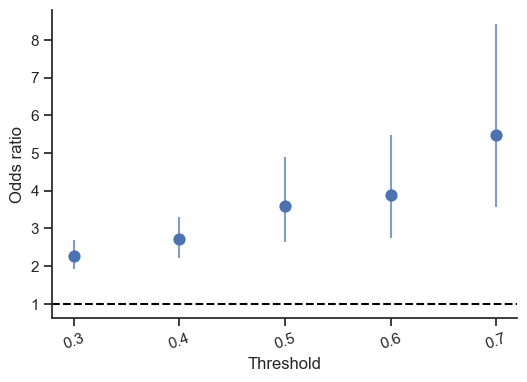

In [38]:
# ── Phase IV+ OR vs resourceScore threshold ──────────────────────────────────
# Vary `indirect_assoc_score_thr` directly — that's the gentropy knob that
# controls which (gene, disease) pairs count as `geneticSupport=True`. The
# function aggregates evidence to a per-pair max via the disease ontology and
# then thresholds on that score, so pre-filtering `evidence_spark` by
# resourceScore has no effect once the internal threshold is stricter.
phase4_rows = []
for thr in np.arange(0.3, 0.71, 0.1):
    thr = round(thr, 2)
    res = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence_spark,
        disease_index_orig=disease_index,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=thr,
    )
    row4 = res[res["clinicalPhase"] == "4+"].iloc[0]
    phase4_rows.append(
        {
            "Threshold": thr,
            "OR": row4["odds_ratio"],
            "ci_L": row4["ci_low"],
            "ci_U": row4["ci_high"],
            "pval": row4["p_value"],
            "n_pairs_supported": row4["total_indirect_assoc"],
        }
    )

phase4_or_DF = pd.DataFrame(phase4_rows)
print(phase4_or_DF.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
sns.pointplot(
    data=phase4_or_DF, x="Threshold", y="OR", linestyle="none", ax=ax
)
ax.vlines(
    x=phase4_or_DF["Threshold"].astype(str),
    ymin=phase4_or_DF["ci_L"],
    ymax=phase4_or_DF["ci_U"],
    alpha=0.7,
)
ax.axhline(y=1, color="black", linestyle="--")
ax.set_ylabel("Odds ratio")
ax.set_xlabel("Threshold")
plt.xticks(rotation=20)
fig.savefig(
    os.path.join(OUT_DIR, "A3b_phase4_OR_vs_resourceScore_nelson.pdf"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()


---

## Analysis 4 — Mechanism of Action Direction Validation

Validates whether VIDRA slope direction (positive → inhibitor, negative → activator)
agrees with known drug mechanism of action from Open Targets.

For oncology indications the dose-response interpretation is inverted (for cancer,
gene *activation* is harmful), so slopes for cancer phenotypes are flipped before
MoA matching. The cancer phenotype list is generated directly from the OT diseases
index in the first cell below (any disease whose `therapeuticAreas` array contains
the "cancer or benign tumor" node `MONDO_0045024`) — no manual upload required.

In [77]:
# ── Generate cancer phenotype list from the OT diseases parquet ───────────────
# The legacy pipeline used a hand-curated cancer_phenotypes.csv to flip slope
# directions for oncology indications. We regenerate it directly from the OT
# diseases index: any disease whose therapeuticAreas array contains the
# "cancer or benign tumor" node (MONDO_0045024) is treated as a cancer phenotype.
CANCER_TA = "MONDO_0045024"
diseases = pd.read_parquet(local_diseases, columns=["id", "therapeuticAreas"])
cancer_pheno = (
    diseases.explode("therapeuticAreas")
    .loc[lambda d: d["therapeuticAreas"] == CANCER_TA, ["id"]]
    .rename(columns={"id": "efo"})
    .drop_duplicates()
    .reset_index(drop=True)
)
cancer_path = os.path.join(OUT_DIR, "cancer_phenotypes.csv")
cancer_pheno.to_csv(cancer_path, index=False)
print(f"Cancer phenotypes: {len(cancer_pheno):,} EFOs  →  {cancer_path}")

Cancer phenotypes: 2,582 EFOs  →  post_analysis_results/cancer_phenotypes.csv


In [78]:
# ── Flip slopes for cancer phenotypes ────────────────────────────────────
df_moa = vidra_raw[vidra_raw["parameter"] == "slope"].copy()

cancer_efos = set(cancer_pheno["efo"])
is_cancer = df_moa["as_disease"].isin(cancer_efos)
df_moa.loc[is_cancer, "pp_slope_neg"] = 1 - df_moa.loc[is_cancer, "pp_slope_neg"]
df_moa.loc[is_cancer, "pp_slope_pos"] = 1 - df_moa.loc[is_cancer, "pp_slope_pos"]
df_moa.loc[is_cancer, "mean"] = -df_moa.loc[is_cancer, "mean"]

df_moa = df_moa[
    threshold_df(df_moa, threshold_rare=0.70, threshold_other=0.55)
].reset_index(drop=True)
df_moa["MoA_AS"] = df_moa["mean"].apply(
    lambda x: "inhibitor" if x > 0 else "activator"
)
print(f"MoA analysis dataset: {len(df_moa):,} rows")

MoA analysis dataset: 80,634 rows


In [79]:
# ── Credible interval confidence score ────────────────────────────────────
pct_cols = [c for c in df_moa.columns if c.startswith("pct_")]

def _count_concordant_pct(row):
    return sum(row["mean"] * row[c] >= 0 for c in pct_cols if pd.notna(row[c]))

df_moa["confidence"] = df_moa.apply(_count_concordant_pct, axis=1)
df_moa["confidence_norm"] = df_moa["confidence"] / max(len(pct_cols), 1)

In [80]:
# ── Load OT molecule + mechanismOfAction data (self-contained) ────────────────
# Build molInfo from the UNFILTERED molecule parquet here so Analysis 4 does not
# inherit the clinical-phase-1-4 filter that Analysis 3b applies to moleculeInfo.
# Analysis 3b is not part of the legacy pipeline and must not influence the MoA
# validation — the legacy used all molecules regardless of trial phase. A distinct
# variable name (molInfo_a4) avoids reusing or overwriting the A3/A3b globals.
moleculeInfo_a4 = pd.read_parquet(local_molecule)
_targets_a4 = pd.json_normalize(moleculeInfo_a4["linkedTargets"])
_targets_a4.columns = ["targetId", "targetcount"]
_diseases_a4 = pd.json_normalize(moleculeInfo_a4["linkedDiseases"])
_diseases_a4.columns = ["diseaseId", "diseasecount"]
molInfo_a4 = pd.concat(
    [
        moleculeInfo_a4[
            ["id", "yearOfFirstApproval", "maximumClinicalTrialPhase", "isApproved"]
        ],
        _targets_a4,
        _diseases_a4,
    ],
    axis=1,
).dropna(subset=["targetId", "diseaseId"])
molInfo_a4 = molInfo_a4.explode("targetId").explode("diseaseId")
molInfo_a4.dropna(subset=["targetId", "diseaseId"], inplace=True)

drugInfo = pd.read_parquet(local_moa)
drugInfo.drop(columns=["references"], inplace=True, errors="ignore")

remove_types = [
    "protein family",
    "protein complex",
    "protein complex group",
    "chimeric protein",
    "nucleic-acid",
    "selectivity group",
]
drugInfo = drugInfo[~drugInfo["targetType"].isin(remove_types)]
drugInfo = drugInfo.explode("targets").explode("chemblIds")
drugInfo.dropna(subset=["targets", "chemblIds"], inplace=True)

molInfoMoA = molInfo_a4.merge(
    drugInfo,
    left_on=["id", "targetId"],
    right_on=["chemblIds", "targets"],
    how="inner",
)
print(f"MoA drug-target pairs: {len(molInfoMoA):,}")

MoA drug-target pairs: 45,488


In [81]:
# ── Classify drug MoA ─────────────────────────────────────────────────────
INHIBITORS = {
    "RNA INHIBITOR",
    "NEGATIVE MODULATOR",
    "NEGATIVE ALLOSTERIC MODULATOR",
    "ANTAGONIST",
    "ANTISENSE INHIBITOR",
    "BLOCKER",
    "INHIBITOR",
    "DEGRADER",
    "INVERSE AGONIST",
    "ALLOSTERIC ANTAGONIST",
    "DISRUPTING AGENT",
}
ACTIVATORS = {
    "PARTIAL AGONIST",
    "ACTIVATOR",
    "POSITIVE ALLOSTERIC MODULATOR",
    "POSITIVE MODULATOR",
    "AGONIST",
    "SEQUESTERING AGENT",
    "STABILISER",
}

def _classify_moa(action_type: str) -> str:
    upper = str(action_type).upper()
    if any(k in upper for k in ACTIVATORS):
        return "activator"
    if any(k in upper for k in INHIBITORS):
        return "inhibitor"
    return "other"

drugInfoHI = molInfoMoA.copy()
drugInfoHI["MoA"] = drugInfoHI["actionType"].apply(_classify_moa)

In [82]:
# ── Merge drug MoA with VIDRA results ─────────────────────────────────────
consistency_DF = drugInfoHI[
    [
        "diseaseId",
        "id",
        "mechanismOfAction",
        "maximumClinicalTrialPhase",
        "targetId",
        "MoA",
    ]
].merge(
    df_moa,
    left_on=["diseaseId", "targetId"],
    right_on=["as_disease", "gene"],
    how="inner",
)
print(f"Consistency DF: {len(consistency_DF):,} rows")

Consistency DF: 570 rows


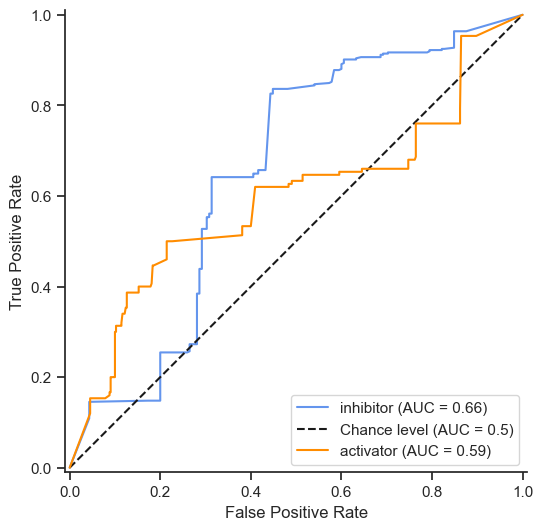

In [83]:
# ── ROC curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
for class_of_interest, color in [
    ("inhibitor", "cornflowerblue"),
    ("activator", "darkorange"),
]:
    dummy = pd.get_dummies(consistency_DF["MoA"])
    if class_of_interest not in dummy.columns:
        continue
    pp = (
        consistency_DF["pp_slope_pos"]
        if class_of_interest == "inhibitor"
        else consistency_DF["pp_slope_neg"]
    )
    RocCurveDisplay.from_predictions(
        dummy[[class_of_interest]],
        pp,
        name=class_of_interest,
        curve_kwargs={"color": color},
        ax=ax,
        plot_chance_level=(class_of_interest == "inhibitor"),
    )
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate")
fig.savefig(os.path.join(OUT_DIR, "A4_AUROC_MoA.pdf"), dpi=600, bbox_inches="tight")
plt.show()

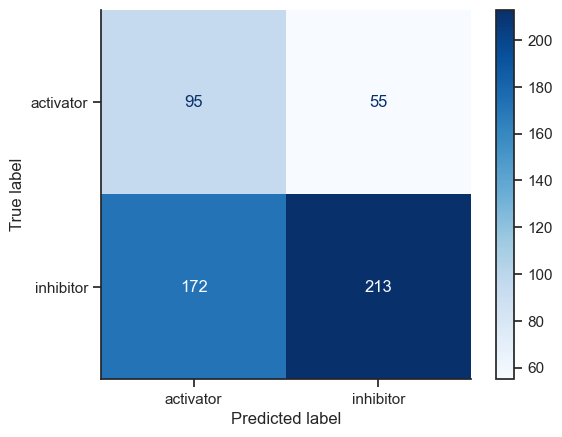

In [84]:
# ── Confusion matrix ──────────────────────────────────────────────────────
cm_df = consistency_DF[consistency_DF["MoA"] != "other"]
cm = confusion_matrix(cm_df["MoA"], cm_df["MoA_AS"], labels=cm_df["MoA"].unique())
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=cm_df["MoA"].unique()
)
disp.plot(cmap="Blues")
plt.savefig(
    os.path.join(OUT_DIR, "A4_confusion_matrix.pdf"), dpi=600, bbox_inches="tight"
)
plt.show()

/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_44986/1997222210.py:6: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



inhibitor: AUC=0.655  p=1e-12


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_44986/1997222210.py:6: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



activator: AUC=0.594  p=0.0001


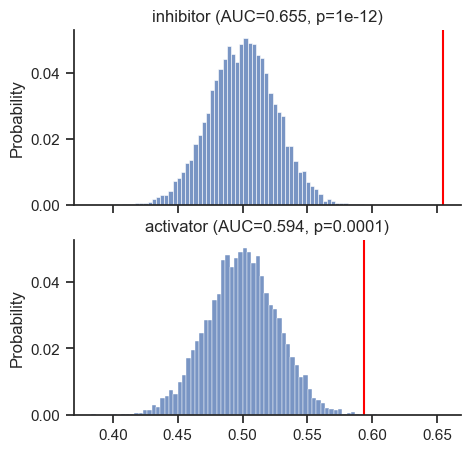

In [85]:
# ── Permutation tests for AUC significance ────────────────────────────────
N_PERM = 10_000
perm_results = {}

for label, col in [("inhibitor", "pp_slope_pos"), ("activator", "pp_slope_neg")]:
    y_true = consistency_DF["MoA"].replace(
        {"activator": 0, "inhibitor": 0, "other": 0}
    )
    y_true = consistency_DF["MoA"] == label
    y_score = consistency_DF[col]
    obs_auc = roc_auc_score(y_true.astype(int), y_score)
    perm_aucs = []
    count = 0
    for _ in range(N_PERM):
        y_perm = np.random.permutation(y_true.astype(int))
        p_auc = roc_auc_score(y_perm, y_score)
        perm_aucs.append(p_auc)
        if p_auc >= obs_auc:
            count += 1
    p_val = (count + 1e-8) / (N_PERM + 1e-8)
    perm_results[label] = {"obs_auc": obs_auc, "p_value": p_val, "dist": perm_aucs}
    print(f"{label}: AUC={obs_auc:.3f}  p={p_val:.4g}")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(5, 5))
for ax, label in zip(axes, ["inhibitor", "activator"]):
    r = perm_results[label]
    sns.histplot(r["dist"], ax=ax, stat="probability")
    ax.axvline(r["obs_auc"], color="red")
    ax.set_title(f"{label} (AUC={r['obs_auc']:.3f}, p={r['p_value']:.4g})")
fig.savefig(
    os.path.join(OUT_DIR, "A4_AUROC_permutation_test.pdf"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

In [86]:
# ── Confidence-stratified ROC + chi-squared stats ─────────────────────────
list_out = []
for cred in sorted(consistency_DF["confidence"].unique()):
    tmp = consistency_DF[consistency_DF["confidence"] >= cred]

    fig, ax = plt.subplots(figsize=(6, 6))
    for class_of_interest, color in [
        ("inhibitor", "cornflowerblue"),
        ("activator", "darkorange"),
    ]:
        dummy = pd.get_dummies(tmp["MoA"])
        if class_of_interest not in dummy.columns:
            continue
        pp = (
            tmp["pp_slope_pos"]
            if class_of_interest == "inhibitor"
            else tmp["pp_slope_neg"]
        )
        RocCurveDisplay.from_predictions(
            dummy[[class_of_interest]],
            pp,
            name=class_of_interest,
            curve_kwargs={"color": color},
            ax=ax,
            plot_chance_level=(class_of_interest == "inhibitor"),
        )
    ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=f"confidence >= {cred}",
    )
    fig.savefig(
        os.path.join(OUT_DIR, f"A4_ROC_confidence_{cred}.pdf"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.close()

    tmp_no_other = tmp[tmp["MoA"] != "other"]
    if len(tmp_no_other) < 4:
        continue
    cm = confusion_matrix(
        tmp_no_other["MoA"],
        tmp_no_other["MoA_AS"],
        labels=tmp_no_other["MoA"].unique(),
    )
    ConfusionMatrixDisplay(cm, display_labels=tmp_no_other["MoA"].unique()).plot(
        cmap="Blues"
    ).figure_.savefig(
        os.path.join(OUT_DIR, f"A4_confusion_matrix_confidence_{cred}.pdf"),
        dpi=300,
    )
    plt.close()

    chi2, p, dof, _ = chi2_contingency(cm)
    TN, FP, FN, TP = cm.ravel()
    OR = ((TP + 0.1) * (TN + 0.1)) / ((FP + 0.1) * (FN + 0.1))
    list_out.append(
        {
            "cred": cred,
            "n_drugs": len(tmp_no_other),
            "chi2": chi2,
            "p_value": p,
            "dof": dof,
            "OR": OR,
            "TP": TP,
            "TN": TN,
            "FP": FP,
            "FN": FN,
        }
    )

chi2_df = pd.concat([pd.DataFrame([r]) for r in list_out])
chi2_path = os.path.join(OUT_DIR, "A4_chi2_MoA_directionality_stats.csv")
chi2_df.to_csv(chi2_path, index=False)
print(f"Chi-squared stats saved → {chi2_path}")
print(chi2_df.to_string(index=False))

Chi-squared stats saved → post_analysis_results/A4_chi2_MoA_directionality_stats.csv
 cred  n_drugs      chi2  p_value  dof        OR  TP  TN  FP  FN
    0      535 14.294025 0.000156    1  2.137133 213  95  55 172
    4      532 14.501176 0.000140    1  2.156208 211  95  54 172
    5      451  3.325681 0.068206    1  1.494032 136  94  50 171
    6      334  6.652513 0.009902    1  1.837285  97  91  50  96
    7      331  5.908498 0.015068    1  1.780520  94  91  50  96
    8      288 13.605857 0.000225    1  2.494402  87  89  50  62
    9      199  4.971775 0.025764    1  1.973098  59  57  46  37
   10      103 14.578682 0.000134    1  6.978896  23  48  26   6
   12       90 22.916907 0.000002    1 12.359144  22  48  14   6
   13       82 18.667907 0.000016    1 10.303569  22  40  14   6


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_44986/3246555426.py:35: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.

/Users/dc16/gentropy/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



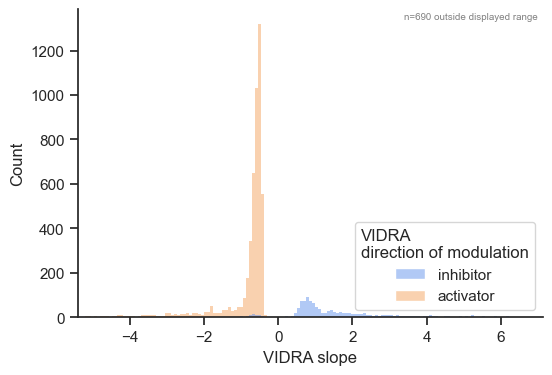

In [87]:
# ── Figure 4b — distribution of VIDRA slopes by inferred direction ────────
# One row per priority gene: the slope with the largest |median| (legacy-faithful,
# confustion_matrix_ROCs_enrichment_directionality_new.py:309-311).
df_moa["predicted"] = df_moa["gene"].isin(priority_genes["gene"])
idx = df_moa.groupby("gene")["median"].apply(lambda x: x.abs().idxmax())
max_abs_medians = df_moa.loc[idx]
panel_b = max_abs_medians[max_abs_medians["predicted"]]

# Clip display to the 1-99th percentile: the new pipeline produces a few
# extreme slopes (|slope| up to ~10^3) that otherwise compress the bulk of
# the distribution into a single bin. Data is not filtered, only the x-range.
lo, hi = panel_b["median"].quantile([0.05, 0.95])
n_out = int(((panel_b["median"] < lo) | (panel_b["median"] > hi)).sum())

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(
    data=panel_b,
    x="median",
    hue="MoA_AS",
    hue_order=["inhibitor", "activator"],
    palette={"inhibitor": "cornflowerblue", "activator": "sandybrown"},
    bins=50000,
    ax=ax,
)
ax.set_xlim(lo, hi)
ax.set_xlabel("VIDRA slope")
ax.set_ylabel("Count")
leg = ax.get_legend()
if leg is not None:
    leg.set_title("VIDRA\ndirection of modulation")
if n_out:
    ax.text(0.99, 0.99, f"n={n_out} outside displayed range",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=7, color="grey")
fig.savefig(
    os.path.join(OUT_DIR, "A4_slope_distribution_by_direction.pdf"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

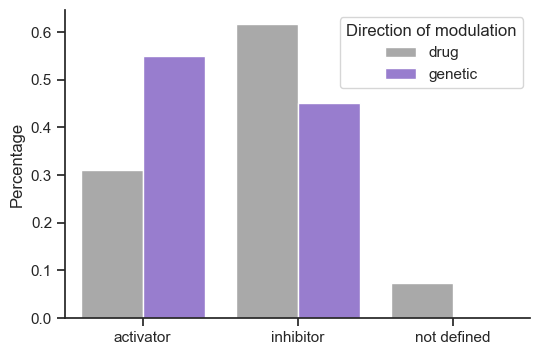

source        drug  genetic
type                       
activator    0.311     0.55
inhibitor    0.616     0.45
not defined  0.073     0.00


In [88]:
# ── Figure 4c — direction of modulation: drug annotation vs VIDRA ─────────
# Drug (external annotation): proportions across ALL drug-target MoA calls.
# Genetic (VIDRA): proportions across ALL thresholded VIDRA slope directions.
# VIDRA only ever calls inhibitor/activator (sign of the slope), never
# "not defined" — so that bar is zero for genetic. Mirrors the legacy
# df_barplot in confustion_matrix_ROCs_enrichment_directionality_new.py:315-328,
# but computed from the data instead of hardcoded counts.
drug_counts = drugInfoHI["MoA"].value_counts()
genetic_counts = df_moa["MoA_AS"].value_counts()

rows = []
for cat in ["activator", "inhibitor", "other"]:
    rows.append({"source": "drug", "type": cat, "n": int(drug_counts.get(cat, 0))})
    rows.append({"source": "genetic", "type": cat, "n": int(genetic_counts.get(cat, 0))})
bar_df = pd.DataFrame(rows)
bar_df["Percentage"] = bar_df["n"] / bar_df.groupby("source")["n"].transform("sum")
bar_df["type"] = bar_df["type"].replace({"other": "not defined"})

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=bar_df,
    x="type",
    y="Percentage",
    hue="source",
    order=["activator", "inhibitor", "not defined"],
    hue_order=["drug", "genetic"],
    palette={"drug": "darkgrey", "genetic": "mediumpurple"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Percentage")
leg = ax.get_legend()
if leg is not None:
    leg.set_title("Direction of modulation")
fig.savefig(
    os.path.join(OUT_DIR, "A4_direction_proportion_drug_vs_genetic.pdf"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

print(bar_df.pivot(index="type", columns="source", values="Percentage").round(3))

---

## Summary of outputs

All files are saved to `./post_analysis_results/`:

| File                                             | Analysis                                            |
| ------------------------------------------------ | --------------------------------------------------- |
| `A1_dose_response_correlation.pdf`               | 1 — clinical trial scatter/regression               |
| `A2_metabolite_disease_general.pdf`              | 2 — metabolite-disease (concordant/discordant)      |
| `A2_metabolite_disease_quadrants.pdf`            | 2 — metabolite-disease (four quadrants)             |
| `A2_bootstrap_distributions.pdf`                 | 2 — permutation test distributions                  |
| `A3_priority_score_distribution.pdf`             | 3 — priority score on test set                      |
| `A3_priority_score_all_genes.pdf`                | 3 — priority score all genes (TYK2/PCSK9 annotated) |
| `A3_OR_enrichment.pdf`                           | 3 — forest plot of enrichment ORs                   |
| `genelist_with_priorityScore_greater_than07.csv` | 3 — high-priority gene list                         |
| `A4_AUROC_MoA.pdf`                               | 4 — Fig 4a: ROC curves (inhibitor/activator)        |
| `A4_slope_distribution_by_direction.pdf`         | 4 — Fig 4b: slope distribution by direction         |
| `A4_direction_proportion_drug_vs_genetic.pdf`    | 4 — Fig 4c: direction proportion drug vs VIDRA      |
| `A4_confusion_matrix.pdf`                         | 4 — MoA confusion matrix                            |
| `A4_AUROC_permutation_test.pdf`                  | 4 — AUC permutation distributions                   |
| `A4_ROC_confidence_*.pdf`                        | 4 — per-confidence ROC curves                       |
| `A4_confusion_matrix_confidence_*.pdf`           | 4 — per-confidence confusion matrices               |
| `A4_chi2_MoA_directionality_stats.csv`           | 4 — chi-squared and OR statistics                   |